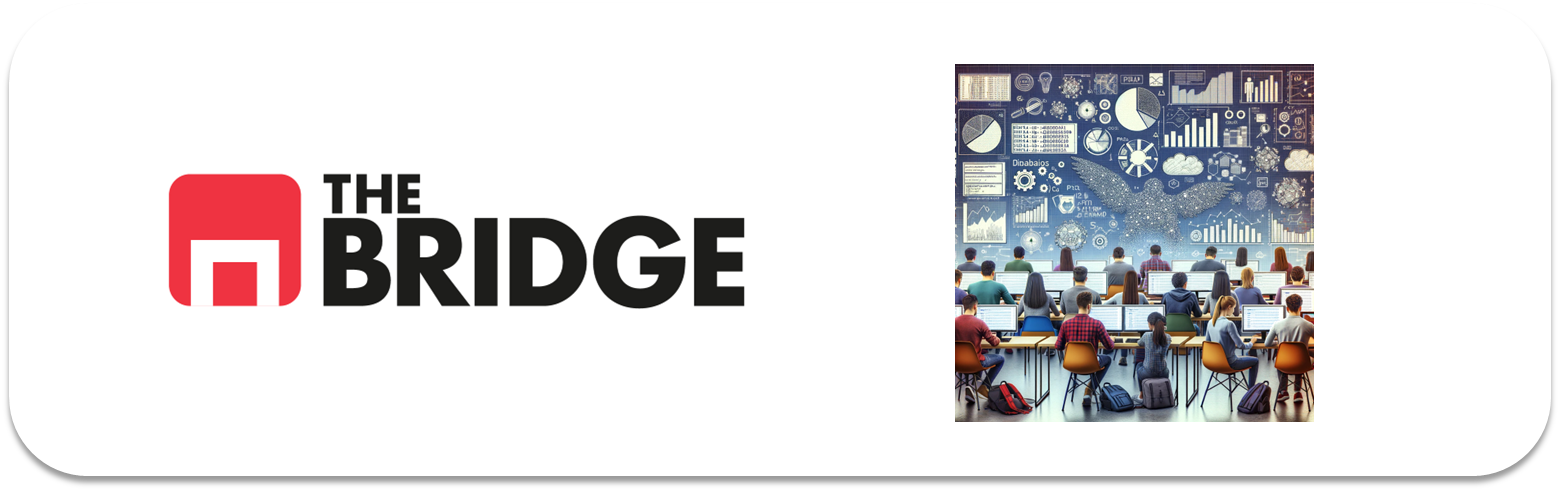

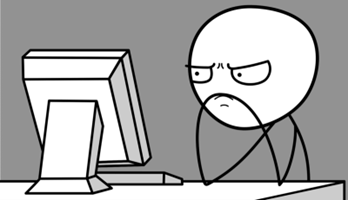

Para ejercitarte y afianzar lo aprendido sobre **Proceso de Datos**, como primera etapa de ML, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Configuración básica para los gráficos
sns.set_theme(style="whitegrid")

### Ejercicio 1

Carga el dataset de advertising que encontrarás en la carpeta de datos. Muestra su información general. ¿Qué te llama la atención? ¿Tendremos que limpiar alguna variable?

In [12]:
# Carga del dataset (asumiendo formato csv habitual)
df = pd.read_csv("data/advertising_ml.csv")

# Mostrar información general
print(df.info())
print("\nPrimeras filas:")
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   str    
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   str    
 5   City                      1000 non-null   str    
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   str    
 8   Timestamp                 1000 non-null   str    
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(2), str(5)
memory usage: 78.3 KB
None

Primeras filas:
   Daily Time Spent on Site       Age  Area Income  Daily Internet Usage  \
0                     68.95  35 years     61833.90                256.09   
1           

Tipos de datos: Habitualmente este dataset contiene columnas de tipo texto (como Ad Topic Line, City, Country y Timestamp) que tienen una cardinalidad muy alta. No se pueden meter directamente a un modelo matemático sin procesar.

Limpieza: La columna Timestamp suele venir como string, por lo que habría que parsearla a formato fecha (datetime) si queremos extraer variables temporales (hora del día, día de la semana). Las columnas de texto con demasiadas categorías únicas normalmente se descartan en una primera aproximación o se transforman radicalmente.

### Ejercicio 2

Tenemos que entender el problema antes de seguir. Nos dicen que la compañía "QuickRespond" quiere poder generar un modelo que a partir de datos como los del dataset para poder dirigir mejor su campaña de anuncios. Hablando con ellos llegamos a la conclusión de que queremos un modelo para poder predecir si un usuario pulsará en el link de un anuncio o no. ¿Qué tipo de problemas estamos tratando?¿Y de que tipo de aprendizaje?¿Existe una variable target que puedas identificar rapidamente?

Tipo de problema: Es un problema de Clasificación Binaria, ya que el resultado que buscamos predecir tiene solo dos opciones mutuamente excluyentes (Pulsar el link = Sí / No).

Tipo de aprendizaje: Es Aprendizaje Supervisado (Supervised Learning), dado que entrenaremos al modelo utilizando un conjunto de datos histórico que ya contiene la respuesta correcta (etiquetas).

Variable Target: Sí, la variable objetivo se identifica rápidamente en este dataset bajo el nombre de Clicked on Ad (habitualmente codificada con 1 para el "Sí" y 0 para el "No").

### Ejercicio 3

Volvamos ya a los datos. Intenta dar una definicón de cada columna, obten su cardinalidad y en función de esta y del tipo de variable de pandas, clasifícalas en categóricas y numéricas.

In [18]:
# 2. Creamos una función para analizar las columnas y automatizar la tabla
def analizar_variables(dataframe):
    analisis = []
    
    # Diccionario con definiciones estándar del dataset 'Advertising'
    definiciones = {
        'Daily Time Spent on Site': 'Minutos al día que el usuario pasa en la página web.',
        'Age': 'Edad del usuario en años.',
        'Area Income': 'Ingreso promedio de la zona geográfica donde reside el usuario.',
        'Daily Internet Usage': 'Minutos promedio al día que el usuario navega por internet.',
        'Ad Topic Line': 'Texto o titular principal del anuncio publicitario.',
        'City': 'Ciudad de residencia del usuario.',
        'Male': 'Género del usuario (1 si es hombre, 0 si es mujer).',
        'Country': 'País de residencia del usuario.',
        'Timestamp': 'Fecha y hora exacta en la que el usuario visualizó el anuncio.',
        'Clicked on Ad': 'Variable objetivo. Indica si hizo clic (1) o no (0) en el anuncio.'
    }
    
    for col in dataframe.columns:
        cardinalidad = dataframe[col].nunique()
        tipo_pandas = str(dataframe[col].dtype)
        
        # Lógica de clasificación básica basada en tipo de datos y cardinalidad
        if col == 'Clicked on Ad':
            tipo_variable = 'Target / Categórica Binaria'
        elif cardinalidad == 2:
            tipo_variable = 'Categórica Binaria'
        elif tipo_pandas in ['int64', 'float64'] and cardinalidad > 15:
            tipo_variable = 'Numérica Continua'
        elif tipo_pandas in ['int64', 'float64'] and cardinalidad <= 15:
            tipo_variable = 'Numérica Discreta'
        elif 'datetime' in tipo_pandas or col == 'Timestamp':
            tipo_variable = 'Temporal (Datetime)'
        else:
            tipo_variable = 'Categórica Textual'
            
        analisis.append({
            'Columna': col,
            'Definición': definiciones.get(col, 'Sin definición disponible.'),
            'Cardinalidad': cardinalidad,
            'Tipo Pandas': tipo_pandas,
            'Clasificación': tipo_variable
        })
        
    return pd.DataFrame(analisis)

# Ejecutamos la función
df_resultado = analizar_variables(df)

# Mostrar el resultado en el entorno de Python
print(df_resultado)

                     Columna  \
0   Daily Time Spent on Site   
1                        Age   
2                Area Income   
3       Daily Internet Usage   
4              Ad Topic Line   
5                       City   
6                       Male   
7                    Country   
8                  Timestamp   
9              Clicked on Ad   
10                      Hour   
11                     Month   
12                 DayOfWeek   

                                           Definición  Cardinalidad  \
0   Minutos al día que el usuario pasa en la págin...           900   
1                           Edad del usuario en años.            83   
2   Ingreso promedio de la zona geográfica donde r...          1000   
3   Minutos promedio al día que el usuario navega ...           966   
4   Texto o titular principal del anuncio publicit...          1000   
5                   Ciudad de residencia del usuario.           969   
6   Género del usuario (1 si es hombre, 0 si es mu... 

| Columna | Definición | Cardinalidad | Tipo Pandas | Clasificación |
| :--- | :--- | :---: | :---: | :--- |
| **Daily Time Spent on Site** | Minutos al día que el usuario pasa en la página web. | Alta (~900) | `float64` | Numérica Continua |
| **Age** | Edad del usuario en años. | Media (~43) | `int64` | Numérica Discreta |
| **Area Income** | Ingreso promedio de la zona geográfica donde reside el usuario. | Alta (~1000) | `float64` | Numérica Continua |
| **Daily Internet Usage** | Minutos promedio al día que el usuario navega por internet. | Alta (~966) | `float64` | Numérica Continua |
| **Ad Topic Line** | Texto o titular principal del anuncio publicitario. | 1000 | `object` | Categórica Textual |
| **City** | Ciudad de residencia del usuario. | 969 | `object` | Categórica |
| **Male** | Género del usuario (1 si es hombre, 0 si es mujer). | 2 | `int64` | Categórica Binaria |
| **Country** | País de residencia del usuario. | 237 | `object` | Categórica |
| **Timestamp** | Fecha y hora exacta en la que el usuario visualizó el anuncio. | 1000 | `object` | Temporal (Datetime) |
| **Clicked on Ad** | Variable objetivo. Indica si hizo clic (1) o no (0) en el anuncio. | 2 | `int64` | **Variable Target** |

### Ejercicio 4

Limpia las columnas que necesiten ser limpiadas, no completes nulos (porque asignar valores a nulos sólo puedes hacerlo primero con el train, ya explicaremos con detalle por qué). 

In [13]:
# Convertir Timestamp a tipo datetime para que sea manejable
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extraer características numéricas útiles del tiempo antes de descartar la original
df['Hour'] = df['Timestamp'].dt.hour
df['Month'] = df['Timestamp'].dt.month
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

# Eliminamos las columnas de texto de altísima cardinalidad que no aportan valor directo
# sin técnicas avanzadas de NLP o codificación masiva
df_cleaned = df.drop(columns=['Ad Topic Line', 'City', 'Country', 'Timestamp'])

### Ejercicio 5

Divide el datset en train y test, empleando sklearn para ello tal y como hemos hecho en el workout. Usa la regla del 80-20

In [14]:
# Separamos las características (X) de nuestra variable objetivo (y)
X = df_cleaned.drop(columns=['Clicked on Ad'])
y = df_cleaned['Clicked on Ad']

# División 80% entrenamiento y 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")

Dimensiones de X_train: (800, 8)
Dimensiones de X_test: (200, 8)


### Ejercicio 6

Haz un pequeño análisis univariante de las columnas numéricas (muestra sus histogramas)

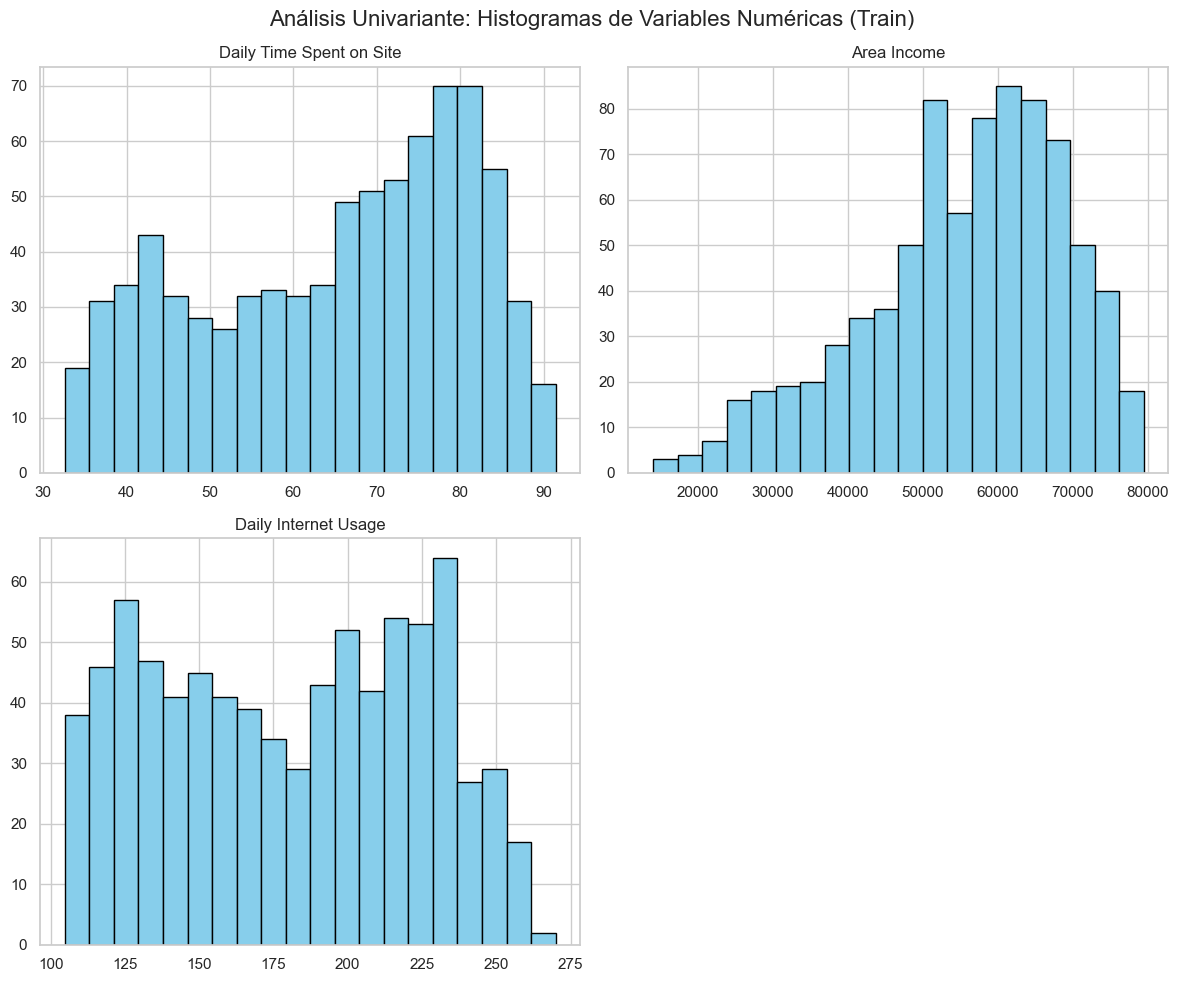

In [15]:
# Seleccionamos las columnas que son puramente continuas/numéricas
numeric_cols = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']

# Dibujar los histogramas
X_train[numeric_cols].hist(bins=20, figsize=(12, 10), color='skyblue', edgecolor='black')
plt.suptitle('Análisis Univariante: Histogramas de Variables Numéricas (Train)', fontsize=16)
plt.tight_layout()
plt.show()

### Ejercicio 7

Muestra las correlaciones de las variables continuas con un "PairPlot" y emplea como codigo de color la variable target. [Esto es otra forma de hacer un bivariante y un multivariante a la vez]. Para ello como argumento del pairplot de seaborn usa el dataframe de train (no la matriz de correlación)

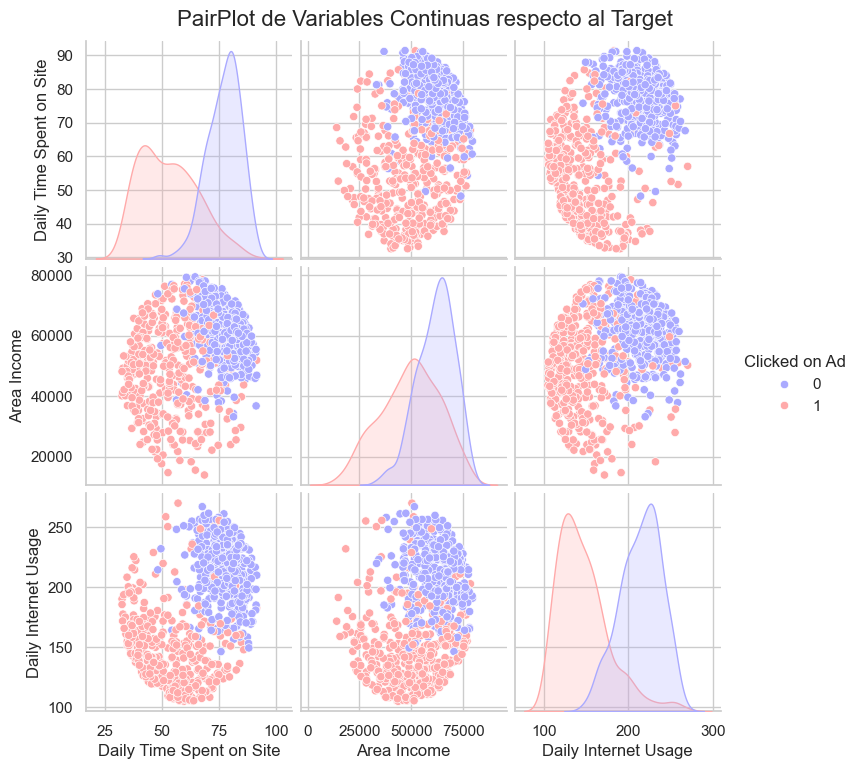

In [16]:
# Combinamos momentáneamente X_train (solo numéricas) con y_train para el gráfico
train_for_plot = X_train[numeric_cols].copy()
train_for_plot['Clicked on Ad'] = y_train

# Generar el PairPlot usando seaborn
sns.pairplot(train_for_plot, hue='Clicked on Ad', palette='bwr', diag_kind='kde')
plt.suptitle('PairPlot de Variables Continuas respecto al Target', y=1.02, fontsize=16)
plt.show()

### Ejercicio 8

Fijándote en la diagonal principal del gráfico anterior haz una selecció de features:

Al observar la diagonal principal (las estimaciones de densidad kde), notarás que las distribuciones de los usuarios que hacen clic ($1$) y los que no ($0$) se separan de forma muy clara en determinadas variables:Daily Internet Usage y Daily Time Spent on Site: En sus respectivas diagonales se ve una separación brutal. Los usuarios que pasan menos tiempo en internet y menos tiempo en el sitio web específico tienden drásticamente a hacer clic en los anuncios (formando picos bimodalmente separados).Age: Los usuarios de mayor edad muestran una tendencia notablemente superior a pulsar el anuncio frente a los más jóvenes.Area Income: Aunque hay solapamiento, las rentas más bajas tienden de forma más marcada a registrar interacciones con la publicidad.



1. Daily Internet Usage
2. Daily Time Spent on StopIteration
3. Age